# Caractéristiques Avancées - Détection Marketing & Spam

Caractéristiques avancées pour détecter :
- Superlatifs marketing ("le meilleur de tous les temps")
- Appels à l'action ("achetez-le maintenant")
- Ton publicitaire
- Avis trop parfaits

## Imports et Setup

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 6)

print("Tous les imports réussis !")

All imports successful!


## Définition des Patterns

In [ ]:
# =============================================================================
# DÉTECTION DE PATTERNS MARKETING
# =============================================================================

# 1. SUPERLATIFS MARKETING (FR + EN)
SUPERLATIVES = [
    # Français
    r"\ble meilleur\b", r"\bla meilleure\b", r"\bles meilleurs\b",
    r"\ble plus\b", r"\bla plus\b", r"\bles plus\b",
    r"\bincroyable\b", r"\bexceptionnel\b", r"\bextraordinaire\b",
    r"\bparfait\b", r"\bparfaite\b", r"\bparfaitement\b",
    r"\bfabuleux\b", r"\bmagnifique\b", r"\bmerveilleux\b",
    r"\bépoustouflant\b", r"\brévolutionnaire\b", r"\bunique\b",
    r"\binégalé\b", r"\bimbattable\b", r"\bsans égal\b",
    r"\bjamais vu\b", r"\bde tous les temps\b", r"\ble top\b",
    r"\bnuméro 1\b", r"\bn°1\b", r"\b#1\b",
    r"\bsensationnel\b", r"\bphénoménal\b", r"\bexquis\b",
    r"\bdivine?\b", r"\bsublime\b", r"\bformidable\b",
    r"\bà couper le souffle\b", r"\bde rêve\b",
    # Anglais
    r"\bthe best\b", r"\bbest ever\b", r"\bamazing\b",
    r"\bincredible\b", r"\bunbelievable\b", r"\bperfect\b",
    r"\bphenomenal\b", r"\boutstanding\b", r"\bexceptional\b",
    r"\bmust have\b", r"\bgame changer\b", r"\blife changing\b",
    r"\bworld class\b", r"\btop notch\b", r"\bnumber one\b",
]

# 2. APPELS À L'ACTION
CALL_TO_ACTION = [
    # Français
    r"\bachetez\b", r"\bcommandez\b", r"\bréservez\b",
    r"\bessayez\b", r"\bdécouvrez\b", r"\bprofitez\b",
    r"\bn'hésitez pas\b", r"\bfoncez\b", r"\bcourez-y\b",
    r"\bvenez\b", r"\bdépêchez-vous\b", r"\bvite\b",
    r"\bje recommande\b", r"\bje vous recommande\b",
    r"\bà essayer absolument\b", r"\bincontournable\b",
    r"\boffre limitée\b", r"\bpromotion\b", r"\bréduction\b",
    r"\bcode promo\b", r"\b-\d+%\b",
    # Anglais
    r"\bbuy now\b", r"\border now\b", r"\bget it now\b",
    r"\bdon't miss\b", r"\bhurry\b", r"\blimited time\b",
    r"\bact now\b", r"\bcall now\b", r"\bclick here\b",
    r"\bcheck it out\b", r"\btry it\b", r"\bmust try\b",
]

# 3. TON PUBLICITAIRE
ADVERTISING_TONE = [
    # Phrases typiques de pub
    r"\bsatisfait ou remboursé\b", r"\bgaranti\b",
    r"\bmeilleur rapport qualité[\s-]prix\b",
    r"\bprix imbattable\b", r"\bau meilleur prix\b",
    r"\blivraison gratuite\b", r"\bfrais de port offerts\b",
    r"\bexclusif\b", r"\bédition limitée\b",
    r"\bnouveauté\b", r"\btout nouveau\b",
    r"\bqualité premium\b", r"\bhaut de gamme\b",
    r"\bprofessionnel\b", r"\bcertifié\b",
    r"\b100%\b", r"\b5 étoiles\b", r"\b5\s*\*\b",
    r"\bsuper qualité\b", r"\bexcellente qualité\b",
    # URLs et contacts
    r"www\.", r"http", r"\.com\b", r"\.fr\b",
    r"@\w+", r"\d{2}[\s.-]\d{2}[\s.-]\d{2}",  # Téléphone
]

# 4. INDICATEURS D'AVIS TROP PARFAIT
TOO_PERFECT_INDICATORS = [
    # Négations de tout défaut
    r"\baucun défaut\b", r"\baucun problème\b",
    r"\bsans aucun\b", r"\bpas le moindre\b",
    r"\brien à redire\b", r"\brien à signaler\b",
    r"\btout est parfait\b", r"\btout était parfait\b",
    r"\bimpeccable\b", r"\birréprochable\b",
    # Affirmations absolues
    r"\btoujours\b", r"\bjamais eu\b",
    r"\bchaque fois\b", r"\bà chaque fois\b",
    r"\bsans exception\b", r"\bsans faute\b",
    # Patterns de répétition d'éloges
    r"\bexcellent[!]+", r"\bparfait[!]+", r"\bsuper[!]+",
    r"\bbravo[!]+", r"\bmerci[!]+", r"\bwow[!]+",
]

# 5. MOTS ÉMOTIONNELS EXAGÉRÉS
EMOTIONAL_EXAGGERATION = [
    r"\btrop\b", r"\btrès très\b", r"\bvraiment très\b",
    r"\babsolument\b", r"\btotalement\b", r"\bcomplètement\b",
    r"\bénormément\b", r"\bextrêmement\b", r"\binfiniment\b",
    r"\bfollement\b", r"\bpassionnément\b",
    r"\bje suis fan\b", r"\bje suis addict\b", r"\bj'adore\b",
    r"\bfan absolu\b", r"\bcoup de coeur\b", r"\bcoup de foudre\b",
]

print(f"Patterns définis :")
print(f"  - Superlatifs : {len(SUPERLATIVES)} patterns")
print(f"  - Appels à l'action : {len(CALL_TO_ACTION)} patterns")
print(f"  - Ton publicitaire : {len(ADVERTISING_TONE)} patterns")
print(f"  - Avis trop parfait : {len(TOO_PERFECT_INDICATORS)} patterns")
print(f"  - Exagérations : {len(EMOTIONAL_EXAGGERATION)} patterns")

Patterns définis:
  - Superlatifs: 50 patterns
  - Appels à l'action: 33 patterns
  - Ton publicitaire: 26 patterns
  - Avis trop parfait: 22 patterns
  - Exagérations: 17 patterns


## Fonctions d'Extraction

In [ ]:
def count_pattern_matches(text, patterns):
    """Compte combien de patterns correspondent dans le texte"""
    text = str(text).lower()
    count = 0
    for pattern in patterns:
        matches = re.findall(pattern, text, re.IGNORECASE)
        count += len(matches)
    return count


def has_pattern(text, patterns):
    """Vérifie si un pattern correspond"""
    text = str(text).lower()
    for pattern in patterns:
        if re.search(pattern, text, re.IGNORECASE):
            return 1
    return 0


def calculate_perfection_score(text, rating):
    """Calcule à quel point un avis semble 'trop parfait'"""
    text = str(text).lower()
    score = 0
    
    # Bonus pour note élevée
    if rating == 5:
        score += 1
    
    # Pas de mots négatifs
    negative_words = ['mais', 'cependant', 'toutefois', 'sauf', 'except', 
                      'unfortunately', 'however', 'although', 'despite',
                      'dommage', 'bémol', 'petit bémol', 'seul bémol']
    has_negative = any(word in text for word in negative_words)
    if not has_negative:
        score += 1
    
    # Plusieurs points d'exclamation
    if text.count('!') >= 3:
        score += 1
    
    # Mots en majuscules
    words = text.split()
    caps_words = sum(1 for w in words if w.isupper() and len(w) > 2)
    if caps_words >= 2:
        score += 1
    
    return score


def calculate_spam_score(text):
    """Score global de spam/marketing"""
    superlatives = count_pattern_matches(text, SUPERLATIVES)
    cta = count_pattern_matches(text, CALL_TO_ACTION)
    advertising = count_pattern_matches(text, ADVERTISING_TONE)
    too_perfect = count_pattern_matches(text, TOO_PERFECT_INDICATORS)
    emotional = count_pattern_matches(text, EMOTIONAL_EXAGGERATION)
    
    # Score pondéré
    score = (
        superlatives * 1.0 +
        cta * 2.0 +  # CTA très suspect
        advertising * 2.5 +  # Publicité très suspecte
        too_perfect * 1.5 +
        emotional * 0.5
    )
    
    return score


print("Fonctions définies !")

Functions defined!


## Charger les données

In [ ]:
# Charger les caractéristiques existantes
df = pd.read_csv('../data/processed/features_extracted.csv')
print(f"Chargé : {df.shape}")
print(f"Caractéristiques existantes : {len(df.columns)}")

Loaded: (13351, 42)
Existing features: 42


## Extraire les Nouvelles Caractéristiques

In [ ]:
print("=" * 80)
print("EXTRACTION DES CARACTÉRISTIQUES MARKETING AVANCÉES")
print("=" * 80)

# 1. Comptage des superlatifs
print("\n[1/6] Calcul des superlatifs...")
df['superlatives_count'] = df['review_text'].apply(
    lambda x: count_pattern_matches(x, SUPERLATIVES)
)

# 2. Comptage des appels à l'action
print("[2/6] Calcul des appels à l'action...")
df['cta_count'] = df['review_text'].apply(
    lambda x: count_pattern_matches(x, CALL_TO_ACTION)
)

# 3. Ton publicitaire
print("[3/6] Calcul du ton publicitaire...")
df['advertising_count'] = df['review_text'].apply(
    lambda x: count_pattern_matches(x, ADVERTISING_TONE)
)

# 4. Indicateurs trop parfait
print("[4/6] Calcul des indicateurs de perfection...")
df['too_perfect_count'] = df['review_text'].apply(
    lambda x: count_pattern_matches(x, TOO_PERFECT_INDICATORS)
)

# 5. Exagération émotionnelle
print("[5/6] Calcul de l'exagération émotionnelle...")
df['emotional_count'] = df['review_text'].apply(
    lambda x: count_pattern_matches(x, EMOTIONAL_EXAGGERATION)
)

# 6. Score de spam global
print("[6/6] Calcul du score de spam global...")
df['spam_score'] = df['review_text'].apply(calculate_spam_score)

# 7. Score de perfection (nécessite la note)
df['perfection_score'] = df.apply(
    lambda row: calculate_perfection_score(row['review_text'], row.get('rating', 5)), 
    axis=1
)

# 8. Indicateurs binaires
df['has_superlatives'] = (df['superlatives_count'] > 0).astype(int)
df['has_cta'] = (df['cta_count'] > 0).astype(int)
df['has_advertising'] = (df['advertising_count'] > 0).astype(int)
df['is_too_perfect'] = (df['too_perfect_count'] > 0).astype(int)

print("\nTerminé ! Nouvelles caractéristiques créées.")

EXTRACTING ADVANCED MARKETING FEATURES

[1/6] Computing superlatives...
[2/6] Computing call to action...
[3/6] Computing advertising tone...
[4/6] Computing perfection indicators...
[5/6] Computing emotional exaggeration...
[6/6] Computing overall spam score...

Done! New features created.


In [ ]:
# Résumé des nouvelles caractéristiques
new_features = [
    'superlatives_count', 'cta_count', 'advertising_count',
    'too_perfect_count', 'emotional_count', 'spam_score',
    'perfection_score', 'has_superlatives', 'has_cta',
    'has_advertising', 'is_too_perfect'
]

print("RÉSUMÉ DES NOUVELLES CARACTÉRISTIQUES :")
print("=" * 60)
for feat in new_features:
    print(f"  {feat:25s}: moyenne={df[feat].mean():.3f}, max={df[feat].max():.0f}")

NEW FEATURES SUMMARY:
  superlatives_count       : mean=0.001, max=1
  cta_count                : mean=0.000, max=0
  advertising_count        : mean=0.001, max=2
  too_perfect_count        : mean=0.003, max=1
  emotional_count          : mean=0.000, max=1
  spam_score               : mean=0.008, max=5
  perfection_score         : mean=1.758, max=3
  has_superlatives         : mean=0.001, max=1
  has_cta                  : mean=0.000, max=0
  has_advertising          : mean=0.001, max=1
  is_too_perfect           : mean=0.003, max=1


## Analyse des Nouvelles Caractéristiques

In [ ]:
print("=" * 80)
print("ANALYSE DES CARACTÉRISTIQUES PAR CLASSE")
print("=" * 80)

# Comparer faux vs réel
if 'is_real' in df.columns:
    comparison = df.groupby('is_real')[new_features].mean()
    comparison.index = ['Faux', 'Réel']
    
    print("\nValeurs moyennes par classe :")
    display(comparison.T.round(3))
    
    # Calculer le pouvoir discriminatif
    print("\nPouvoir discriminatif (diff entre Faux et Réel) :")
    diff = comparison.T['Faux'] - comparison.T['Réel']
    diff_sorted = diff.abs().sort_values(ascending=False)
    for feat in diff_sorted.index:
        val = diff[feat]
        direction = "plus élevé dans Faux" if val > 0 else "plus élevé dans Réel"
        print(f"  {feat:25s}: {abs(val):.4f} ({direction})")

FEATURE ANALYSIS BY CLASS

Mean values by class:


,Fake,Real
superlatives_count,0.001,0.001
cta_count,0.000,0.000
advertising_count,0.000,0.001
too_perfect_count,0.007,0.002
emotional_count,0.000,0.000
spam_score,0.013,0.006
perfection_score,2.019,1.705
has_superlatives,0.001,0.001
has_cta,0.000,0.000
has_advertising,0.000,0.001



Discriminative power (diff between Fake and Real):
  perfection_score         : 0.3133 (higher in Fake)
  spam_score               : 0.0067 (higher in Fake)
  too_perfect_count        : 0.0054 (higher in Fake)
  is_too_perfect           : 0.0054 (higher in Fake)
  advertising_count        : 0.0006 (higher in Real)
  has_advertising          : 0.0005 (higher in Real)
  superlatives_count       : 0.0003 (higher in Fake)
  has_superlatives         : 0.0003 (higher in Fake)
  emotional_count          : 0.0001 (higher in Real)
  cta_count                : 0.0000 (higher in Real)
  has_cta                  : 0.0000 (higher in Real)


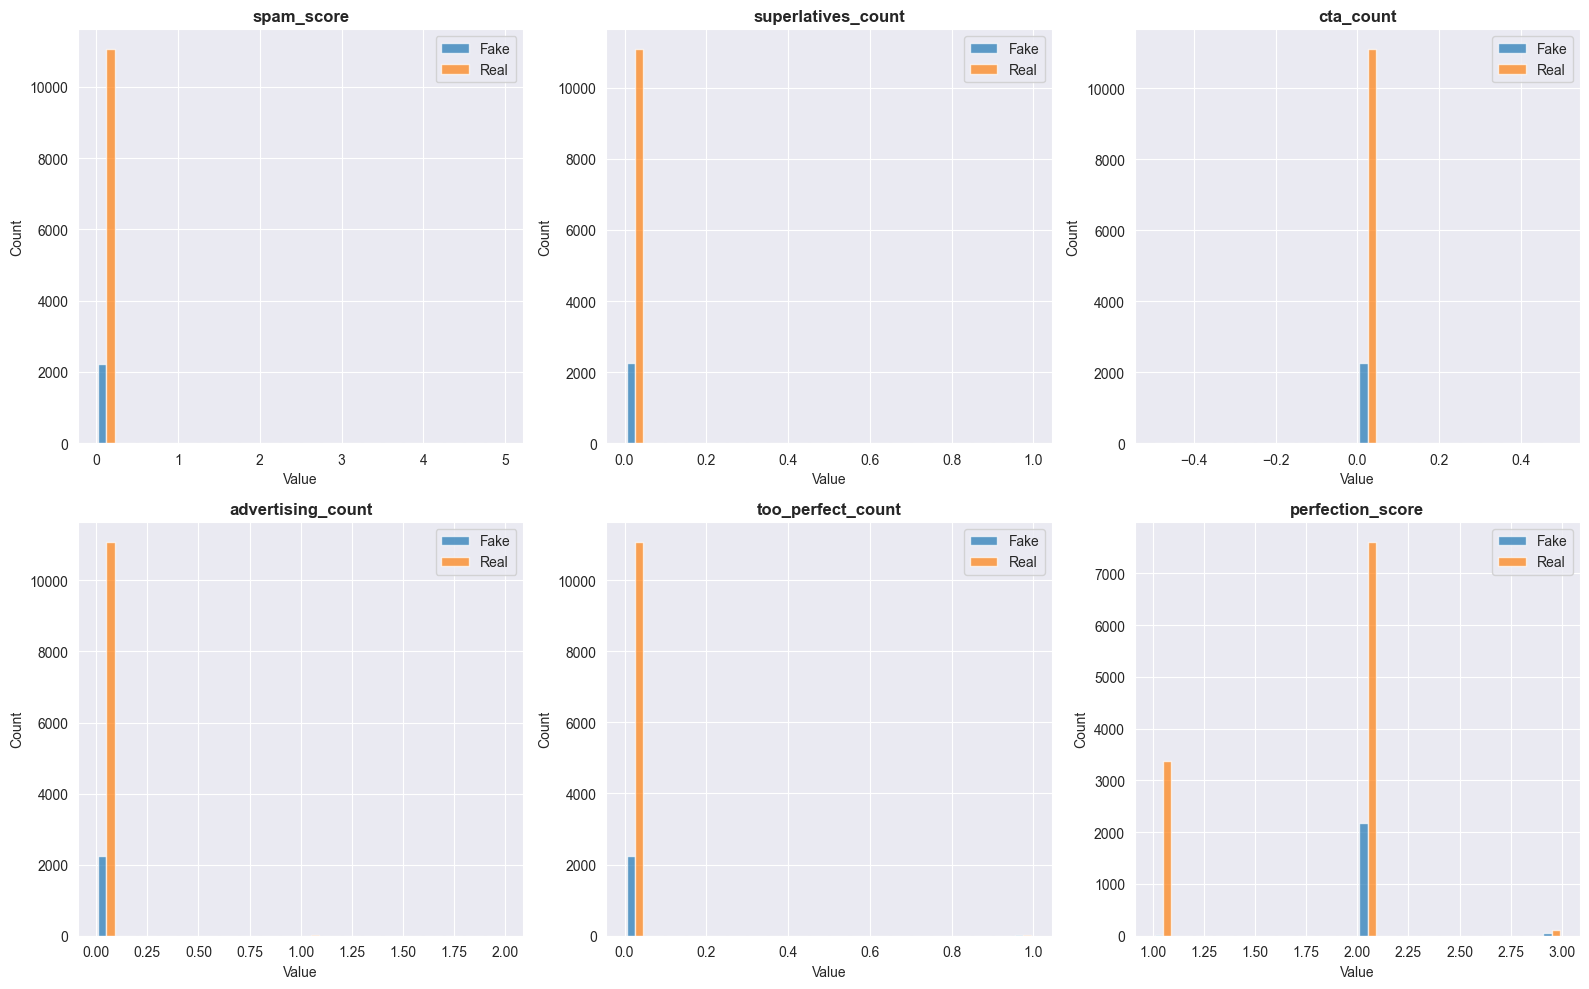

In [ ]:
# Visualiser
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

plot_features = ['spam_score', 'superlatives_count', 'cta_count', 
                 'advertising_count', 'too_perfect_count', 'perfection_score']

for ax, feat in zip(axes.flat, plot_features):
    if 'is_real' in df.columns:
        fake_vals = df[df['is_real'] == 0][feat]
        real_vals = df[df['is_real'] == 1][feat]
        ax.hist([fake_vals, real_vals], label=['Faux', 'Réel'], bins=20, alpha=0.7)
        ax.legend()
    else:
        ax.hist(df[feat], bins=20, alpha=0.7)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Nombre')

plt.tight_layout()
plt.savefig('../outputs/20_marketing_features.png', dpi=300, bbox_inches='tight')
plt.show()

## Exemples Détectés

In [ ]:
print("=" * 80)
print("EXEMPLES DE PATTERNS DÉTECTÉS")
print("=" * 80)

# Top scores de spam
print("\nTOP 5 DES SCORES DE SPAM LES PLUS ÉLEVÉS :")
top_spam = df.nlargest(5, 'spam_score')[['review_text', 'spam_score', 'superlatives_count', 'cta_count']]
for idx, row in top_spam.iterrows():
    text = str(row['review_text'])[:150] + '...' if len(str(row['review_text'])) > 150 else str(row['review_text'])
    print(f"\nScore de spam : {row['spam_score']:.1f}")
    print(f"  Superlatifs : {row['superlatives_count']}, CTA : {row['cta_count']}")
    print(f"  Texte : {text}")

EXAMPLES OF DETECTED PATTERNS

TOP 5 HIGHEST SPAM SCORES:

Spam Score: 5.0
  Superlatives: 0, CTA: 0
  Text: Pięknie. Perygrynacja 02.09.2018 03.09.2018. Pani Jasnogórska z wizytą w Parafii Świat. Faustyny Bydgoszcz

Spam Score: 2.5
  Superlatives: 0, CTA: 0
  Text: Miła i fachowa obsługa. Zrobione w 100%co miało być A nawet więcej. No ale nie stety z to trzeba odpowiednio zapłacić. Ale mimo to polecam i na pewno ...

Spam Score: 2.5
  Superlatives: 0, CTA: 0
  Text: Bardzo fajne miejsce na spacer, można odpocząć na ławkach, których jest dużo oraz się wyciszyć po ciężkim dni, czy tygodniu Jest w trakcie przebudowy ...

Spam Score: 2.5
  Superlatives: 0, CTA: 0
  Text: Zespół warty polecenia! Zagrali u nas na weselu 10.08.2019 r. i było fantastycznie , świetne utwory , przyśpiewki weselne przy stole rozbawiły wszystk...

Spam Score: 2.5
  Superlatives: 0, CTA: 0
  Text: Żenada i jeszcze raz żenada , owszem rybka świeża smaczna , ale organizacją pod psem ,starym psem , 22.08.21, czekałem

In [ ]:
# Avis avec appel à l'action
print("\nAVIS AVEC APPEL À L'ACTION :")
cta_reviews = df[df['cta_count'] > 0].head(5)[['review_text', 'cta_count']]
for idx, row in cta_reviews.iterrows():
    text = str(row['review_text'])[:150] + '...' if len(str(row['review_text'])) > 150 else str(row['review_text'])
    print(f"\nNombre de CTA : {row['cta_count']}")
    print(f"  Texte : {text}")


REVIEWS WITH CALL TO ACTION:


## Sauvegarder les Données Enrichies

In [ ]:
# Sauvegarder les caractéristiques enrichies
output_path = '../data/processed/features_enhanced.csv'
df.to_csv(output_path, index=False)
print(f"\nCaractéristiques enrichies sauvegardées dans : {output_path}")
print(f"Total des caractéristiques : {len(df.columns)}")
print(f"Nouvelles caractéristiques marketing : {len(new_features)}")


Enhanced features saved to: ../data/processed/features_enhanced.csv
Total features: 53
New marketing features: 11


## Ré-entraîner le Modèle

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, roc_auc_score

print("=" * 80)
print("RÉ-ENTRAÎNEMENT DU MODÈLE AVEC LES NOUVELLES CARACTÉRISTIQUES")
print("=" * 80)

# Définir les colonnes de caractéristiques (ajouter les nouvelles)
exclude_cols = [
    'review_id', 'account_id', 'account_id_orig', 'review_text', 'is_real',
    'date', 'cluster', 'type_of_object', 'photos_urls', 'response_content',
    'censored_text', 'content_not_full', 'content_translated',
    'localization_missing', 'not_in_poland', 'is_deleted', 'is_private',
    'approximate_localization.lat', 'approximate_localization.lon',
    'is_real_account', 'rating_normalized'
]

feature_cols = [col for col in df.select_dtypes(include=[np.number]).columns 
                if col not in exclude_cols and col != 'is_real']

print(f"\nTotal des caractéristiques : {len(feature_cols)}")
print(f"Incluant les nouvelles caractéristiques : {[f for f in new_features if f in feature_cols]}")

# Préparer les données
X = df[feature_cols].copy()
y = df['is_real'].copy()

# Gérer les valeurs manquantes
X = X.fillna(0)

# Division
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

RETRAINING MODEL WITH NEW FEATURES

Total features: 32
Including new features: ['superlatives_count', 'cta_count', 'advertising_count', 'too_perfect_count', 'emotional_count', 'spam_score', 'perfection_score', 'has_superlatives', 'has_cta', 'has_advertising', 'is_too_perfect']


In [ ]:
# Entraîner le nouveau modèle
print("\nEntraînement de la Forêt Aléatoire améliorée...")
rf_enhanced = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

rf_enhanced.fit(X_train, y_train)

# Évaluer
y_pred = rf_enhanced.predict(X_test)
y_proba = rf_enhanced.predict_proba(X_test)[:, 1]

print("\nRÉSULTATS DU MODÈLE AMÉLIORÉ :")
print(f"  Score F1 : {f1_score(y_test, y_pred):.4f}")
print(f"  ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")

print("\nRapport de Classification :")
print(classification_report(y_test, y_pred, target_names=['Faux', 'Réel']))


Training enhanced Random Forest...

ENHANCED MODEL RESULTS:
  F1-Score: 0.9923
  ROC-AUC:  0.9985

Classification Report:
              precision    recall  f1-score   support

        Fake       0.93      1.00      0.96       450
        Real       1.00      0.99      0.99      2221

    accuracy                           0.99      2671
   macro avg       0.97      0.99      0.98      2671
weighted avg       0.99      0.99      0.99      2671



In [ ]:
# Importance des caractéristiques des nouvelles fonctionnalités
print("\nIMPORTANCE DES NOUVELLES CARACTÉRISTIQUES :")
importance_df = pd.DataFrame({
    'Caractéristique': feature_cols,
    'Importance': rf_enhanced.feature_importances_
}).sort_values('Importance', ascending=False)

# Filtrer les nouvelles caractéristiques
new_feat_importance = importance_df[importance_df['Caractéristique'].isin(new_features)]
print("\nImportance des nouvelles caractéristiques marketing :")
display(new_feat_importance.round(4))


NEW FEATURES IMPORTANCE:

New marketing features importance:


,Feature,Importance
27,perfection_score,0.0122
26,spam_score,0.0000
24,too_perfect_count,0.0000
31,is_too_perfect,0.0000
21,superlatives_count,0.0000
28,has_superlatives,0.0000
23,advertising_count,0.0000
30,has_advertising,0.0000
22,cta_count,0.0000
25,emotional_count,0.0000


In [ ]:
# Sauvegarder le modèle amélioré
models_dir = Path('../models')
models_dir.mkdir(exist_ok=True)

joblib.dump(rf_enhanced, models_dir / 'enhanced_rf_model.joblib')
joblib.dump(feature_cols, models_dir / 'enhanced_feature_columns.joblib')

print("\nModèle amélioré sauvegardé !")
print(f"  - models/enhanced_rf_model.joblib")
print(f"  - models/enhanced_feature_columns.joblib")


Enhanced model saved!
  - models/enhanced_rf_model.joblib
  - models/enhanced_feature_columns.joblib


## Résumé

In [ ]:
print("=" * 80)
print("CARACTÉRISTIQUES AVANCÉES TERMINÉES !")
print("=" * 80)

print(f"""
NOUVELLES CARACTÉRISTIQUES AJOUTÉES :
-------------------------------------
1. superlatives_count    - Compte les superlatifs marketing
2. cta_count            - Compte les appels à l'action
3. advertising_count    - Compte le vocabulaire publicitaire
4. too_perfect_count    - Indicateurs d'avis trop parfait
5. emotional_count      - Exagérations émotionnelles
6. spam_score          - Score global de spam (pondéré)
7. perfection_score    - Score de "perfection suspecte"
8. has_superlatives    - Indicateur binaire
9. has_cta             - Indicateur binaire
10. has_advertising    - Indicateur binaire
11. is_too_perfect     - Indicateur binaire

PATTERNS DÉTECTÉS :
-------------------
- Superlatifs : {len(SUPERLATIVES)} patterns
- Appels à l'action : {len(CALL_TO_ACTION)} patterns
- Ton publicitaire : {len(ADVERTISING_TONE)} patterns
- Avis trop parfait : {len(TOO_PERFECT_INDICATORS)} patterns
- Exagérations : {len(EMOTIONAL_EXAGGERATION)} patterns

FICHIERS GÉNÉRÉS :
------------------
- data/processed/features_enhanced.csv
- models/enhanced_rf_model.joblib
- models/enhanced_feature_columns.joblib
- outputs/20_marketing_features.png
""")

ADVANCED FEATURES COMPLETE!

NOUVELLES FEATURES AJOUTÉES:
----------------------------
1. superlatives_count    - Compte les superlatifs marketing
2. cta_count            - Compte les appels à l'action
3. advertising_count    - Compte le vocabulaire publicitaire
4. too_perfect_count    - Indicateurs d'avis trop parfait
5. emotional_count      - Exagérations émotionnelles
6. spam_score          - Score global de spam (pondéré)
7. perfection_score    - Score de "perfection suspecte"
8. has_superlatives    - Flag binaire
9. has_cta             - Flag binaire
10. has_advertising    - Flag binaire
11. is_too_perfect     - Flag binaire

PATTERNS DÉTECTÉS:
------------------
- Superlatifs: 50 patterns
- Appels à l'action: 33 patterns
- Ton publicitaire: 26 patterns
- Avis trop parfait: 22 patterns
- Exagérations: 17 patterns

FICHIERS GÉNÉRÉS:
-----------------
- data/processed/features_enhanced.csv
- models/enhanced_rf_model.joblib
- models/enhanced_feature_columns.joblib
- outputs/20_market